Carson Liao

Reading Data

In [ ]:
ranking_data <- read.csv("World University Rankings 2023.csv")

Data

In [ ]:
head(ranking_data)

,University.Rank,Name.of.University,Location,No.of.student,No.of.student.per.staff,International.Student,Female.Male.Ratio,OverAll.Score,Teaching.Score,Research.Score,Citations.Score,Industry.Income.Score,International.Outlook.Score
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,University of Oxford,United Kingdom,"20,965",10.6,42%,48 : 52,96.4,92.3,99.7,99.0,74.9,96.2
2,2,Harvard University,United States,"21,887",9.6,25%,50 : 50,95.2,94.8,99.0,99.3,49.5,80.5
3,3,University of Cambridge,United Kingdom,"20,185",11.3,39%,47 : 53,94.8,90.9,99.5,97.0,54.2,95.8
4,3,Stanford University,United States,"16,164",7.1,24%,46 : 54,94.8,94.2,96.7,99.8,65.0,79.8
5,5,Massachusetts Institute of Technology,United States,"11,415",8.2,33%,40 : 60,94.2,90.7,93.6,99.8,90.9,89.3
6,6,California Institute of Technology,United States,"2,237",6.2,34%,37 : 63,94.1,90.9,97.0,97.3,89.8,83.6


Preprocessing

This code separates the target variable, 'University.Rank', from the rest of the columns in the dataframe 'ranking_data'. The 'target' variable holds the 'University.Rank', and 'df' contains the remaining columns for further analysis or modeling.

In [ ]:
# Assuming 'df' is your dataframe
target <- ranking_data$`University.Rank`
df <- ranking_data[, !names(ranking_data) %in% c("University.Rank")]

This code calculates the count of missing values in each column of the 'df' dataframe using the colSums function with is.na to identify missing values in each column. The result, stored in na_count, will display the number of missing values for each column when printed.

In [ ]:
# Check for missing values in each column
na_count <- colSums(is.na(df))
print(na_count)

         Name.of.University                    Location 
                          0                           0 
              No.of.student     No.of.student.per.staff 
                          0                         133 
      International.Student           Female.Male.Ratio 
                          0                           0 
              OverAll.Score              Teaching.Score 
                          0                           0 
             Research.Score             Citations.Score 
                          0                           0 
      Industry.Income.Score International.Outlook.Score 
                          0                           0 


These lines ensure that the 'Name of University' and 'Location' columns have their missing values replaced with placeholder text, and then checks for any remaining missing values across all columns in the dataframe

In [ ]:
# Assuming 'df' is dataframe

# Filling missing values in 'Name of University' and 'Location'
df$Name.of.University[is.na(df$Name.of.University)] <- "Unknown University"
df$Location[is.na(df$Location)] <- "Unknown Location"

# Checking for missing values
na_count <- colSums(is.na(df))
print(na_count)


         Name.of.University                    Location 
                          0                           0 
              No.of.student     No.of.student.per.staff 
                          0                         133 
      International.Student           Female.Male.Ratio 
                          0                           0 
              OverAll.Score              Teaching.Score 
                          0                           0 
             Research.Score             Citations.Score 
                          0                           0 
      Industry.Income.Score International.Outlook.Score 
                          0                           0 


Fill missing values in specified columns with their respective means and then checks for any remaining missing values across all columns in the dataframe.

In [ ]:
# Assuming 'df' is dataframe

# Columns to fill with mean
columns_to_fill <- c('No.of.student.per.staff', 'Teaching.Score', 'Research.Score', 'Citations.Score', 'Industry.Income.Score', 'International.Outlook.Score')

# Replace NaN values in specified columns with their mean
for (col in columns_to_fill) {
  df[[col]][is.na(df[[col]])] <- mean(df[[col]], na.rm = TRUE)
}

# Checking for missing values
na_count <- colSums(is.na(df))
print(na_count)


Warning message in mean.default(df[[col]], na.rm = TRUE):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(df[[col]], na.rm = TRUE):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(df[[col]], na.rm = TRUE):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(df[[col]], na.rm = TRUE):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(df[[col]], na.rm = TRUE):
“argument is not numeric or logical: returning NA”


         Name.of.University                    Location 
                          0                           0 
              No.of.student     No.of.student.per.staff 
                          0                           0 
      International.Student           Female.Male.Ratio 
                          0                           0 
              OverAll.Score              Teaching.Score 
                          0                           0 
             Research.Score             Citations.Score 
                          0                           0 
      Industry.Income.Score International.Outlook.Score 
                          0                           0 


Data Encoding

'No of student' feature contains numeric value with commas. They are normal value however in string format. For that we have extract those commas and convert into numeric value.

In [ ]:
# Assuming 'df' is dataframe and 'No of student' is the column name

# Remove commas and convert to numeric
df$No.of.student <- as.numeric(gsub(",", "", df$No.of.student))


'International Student' contains the percentage. Hence it is important to convert for handling missing values. We will remove % symbol and turn the string to float and converted to fraction. Some rows contain empty strings to handle we assigned nan values

In [ ]:
# Assuming 'df' is dataframe and 'International.Student' is the column name

library(dplyr)
library(stringr)

# Remove % symbol
df$International.Student <- str_replace(df$International.Student, "%", "")

# Convert to numeric and scale to fractional format (including handling empty strings)
df$International.Student <- ifelse(df$International.Student != "", as.numeric(df$International.Student) / 100, NA)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Female:Male Ratio data needs to be encoded as well. We will seperate them to two new features as integers.

In [ ]:
df

Name.of.University,Location,No.of.student,No.of.student.per.staff,International.Student,Female.Male.Ratio,OverAll.Score,Teaching.Score,Research.Score,Citations.Score,Industry.Income.Score,International.Outlook.Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
University of Oxford,United Kingdom,20965,10.6,0.42,48 : 52,96.4,92.3,99.7,99.0,74.9,96.2
Harvard University,United States,21887,9.6,0.25,50 : 50,95.2,94.8,99.0,99.3,49.5,80.5
University of Cambridge,United Kingdom,20185,11.3,0.39,47 : 53,94.8,90.9,99.5,97.0,54.2,95.8
Stanford University,United States,16164,7.1,0.24,46 : 54,94.8,94.2,96.7,99.8,65.0,79.8
Massachusetts Institute of Technology,United States,11415,8.2,0.33,40 : 60,94.2,90.7,93.6,99.8,90.9,89.3
California Institute of Technology,United States,2237,6.2,0.34,37 : 63,94.1,90.9,97.0,97.3,89.8,83.6
Princeton University,United States,8279,8.0,0.23,46 : 54,92.4,87.6,95.9,99.1,66.0,80.3
"University of California, Berkeley",United States,40921,18.4,0.24,52 : 48,92.1,86.4,95.8,99.0,76.8,78.4
Yale University,United States,13482,5.9,0.21,52 : 48,91.4,92.6,92.7,97.0,55.0,70.9


We used 'tidyr' and 'dplyr' libraries to split the 'Female_Male_Ratio' column in the 'df' dataframe into two separate columns ('Female.Ratio' and 'Male.Ratio') using the 'separate()' function. It then ensures the columns are in numeric format by converting their data types.

In [ ]:
# Assuming 'df' is dataframe and 'Female_Male_Ratio' is the column name

library(tidyr)
library(dplyr)

# Separate 'Female_Male_Ratio' into two columns using separate()
df <- df %>%
  separate(Female.Male.Ratio, into = c("Female.Ratio", "Male.Ratio"), sep = " : ", convert = TRUE)

# Convert columns to numeric format
df$Female.Ratio <- as.numeric(df$Female.Ratio)
df$Male.Ratio <- as.numeric(df$Male.Ratio)

Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 213 rows [11, 16, 17, 39,
45, 56, 58, 61, 67, 74, 81, 86, 111, 118, 135, 146, 164, 165, 171, 172, ...].”


There are both ranged value and single numeric value in OverAll Score. We can take OverAll Score Min and Max

Using 'dplyr' and 'tidyr' libraries to define 'split_scores' as a function to split scores, then applies it to the 'OverAll.Score' column in 'df'. The 'separate()' function splits this column into 'OverAll.Score.Min' and 'OverAll.Score.Max', based on the '–' separator, converting the result to a numeric format.

In [ ]:
library(dplyr)
library(tidyr)

# Function to split scores
split_scores <- function(score) {
  if (typeof(score) == "character") {
    split_values <- unlist(strsplit(score, "–", fixed = TRUE))
    min_val <- as.numeric(split_values[1])
    max_val <- ifelse(length(split_values) == 2, as.numeric(split_values[2]), min_val)
  } else {
    min_val <- max_val <- as.numeric(score)
  }
  return(c(min_val, max_val))
}

# Apply the function to create separate columns
# Separate the 'OverAll.Score' column into 'OverAll.Score.Min' and 'OverAll.Score.Max'
df <- df %>%
  separate(OverAll.Score, into = c("OverAll.Score.Min", "OverAll.Score.Max"), sep = "–", convert = TRUE)


Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 742 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”


In [ ]:
head(df)

,Name.of.University,Location,No.of.student,No.of.student.per.staff,International.Student,Female.Ratio,Male.Ratio,OverAll.Score.Min,OverAll.Score.Max,Teaching.Score,Research.Score,Citations.Score,Industry.Income.Score,International.Outlook.Score
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,University of Oxford,United Kingdom,20965,10.6,0.42,48,52,96.4,NA,92.3,99.7,99.0,74.9,96.2
2,Harvard University,United States,21887,9.6,0.25,50,50,95.2,NA,94.8,99.0,99.3,49.5,80.5
3,University of Cambridge,United Kingdom,20185,11.3,0.39,47,53,94.8,NA,90.9,99.5,97.0,54.2,95.8
4,Stanford University,United States,16164,7.1,0.24,46,54,94.8,NA,94.2,96.7,99.8,65.0,79.8
5,Massachusetts Institute of Technology,United States,11415,8.2,0.33,40,60,94.2,NA,90.7,93.6,99.8,90.9,89.3
6,California Institute of Technology,United States,2237,6.2,0.34,37,63,94.1,NA,90.9,97.0,97.3,89.8,83.6


Name of University and Location are categorical values. We will use one hot encoding.

In [ ]:
# Assuming 'df' is your dataframe and 'column_to_encode' is the column to convert to dummy variables
df <- df %>%
  mutate(Name.of.University = as.factor(Name.of.University))

# Apply one-hot encoding using model.matrix()
encoded_cols <- model.matrix(~ Name.of.University - 1, data = df)
df <- cbind(df, encoded_cols)

# Remove the original column
df <- df %>%
  select(-Name.of.University)


In [ ]:
head(df)

,Location,No.of.student,No.of.student.per.staff,International.Student,Female.Ratio,Male.Ratio,OverAll.Score.Min,OverAll.Score.Max,Teaching.Score,Research.Score,⋯,Name.of.UniversityZewail City of Science and Technology,Name.of.UniversityZhejiang Gongshang University,Name.of.UniversityZhejiang Normal University,Name.of.UniversityZhejiang University,Name.of.UniversityZhejiang University of Finance and Economics,Name.of.UniversityZhejiang University of Technology,Name.of.UniversityZhengzhou University,Name.of.UniversityZhytomyr Polytechnic State University,Name.of.UniversityZiauddin University,Name.of.UniversityZonguldak Bülent Ecevit University
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,United Kingdom,20965,10.6,0.42,48,52,96.4,NA,92.3,99.7,⋯,0,0,0,0,0,0,0,0,0,0
2,United States,21887,9.6,0.25,50,50,95.2,NA,94.8,99.0,⋯,0,0,0,0,0,0,0,0,0,0
3,United Kingdom,20185,11.3,0.39,47,53,94.8,NA,90.9,99.5,⋯,0,0,0,0,0,0,0,0,0,0
4,United States,16164,7.1,0.24,46,54,94.8,NA,94.2,96.7,⋯,0,0,0,0,0,0,0,0,0,0
5,United States,11415,8.2,0.33,40,60,94.2,NA,90.7,93.6,⋯,0,0,0,0,0,0,0,0,0,0
6,United States,2237,6.2,0.34,37,63,94.1,NA,90.9,97.0,⋯,0,0,0,0,0,0,0,0,0,0


Handling Missing Values of Rest of the features

In [ ]:
# Find columns with missing values
missing_cols <- colnames(df)[colSums(is.na(df)) > 0]

# Columns to fill with mean
restColToFillMean <- c('No.of.student', 'International.Student', 'Female.Ratio', 'Male.Ratio', 'OverAll.Score.Min', 'OverAll.Score.Max')

# Fill missing values with column means
for (col in restColToFillMean) {
  if (col %in% missing_cols) {
    df[[col]] <- ifelse(is.na(df[[col]]), mean(df[[col]], na.rm = TRUE), df[[col]])
  }
}



Splitting Dataset

We have our dataset preprocessed for splitting it. We will train on 70% of the dataset and test on 30% of it.

In [ ]:
# Assuming 'df' is your dataset and 'target' is your response variable
install.packages("caret")
library(caret)

# Set seed for reproducibility
set.seed(123)

# Create training and testing indices
trainIndex <- createDataPartition(target, p = 0.7, list = FALSE)

# Split the data into training and testing sets
x_train <- df[trainIndex, ]
y_train <- target[trainIndex]

x_test <- df[-trainIndex, ]
y_test <- target[-trainIndex]


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘Rcpp’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Loading required package: ggplot2

Loading required package: lattice

Warning message in createDataPartition(target, p = 0.7, list = FALSE):
“Some classes have a single record ( 1, 10, 106, 107, 110, 111, 112, 113, 117, 118, 121, 122, 123, 126, 127, 13, 130, 133, 134, 135, 136, 14, 144, 145, 146, 147, 15, 154, 155, 16, 160, 17, 173, 174, 175, 179, 18, 180, 181, 182, 185, 186, 19, 191, 2, 20, 21, 22, 23, 24, 25, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 5, 50, 51, 52, 53, 56, 57, 58, 59, 6, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 7, 70, 73,

Model Training

We will train the decision tree model

In [ ]:
# Assuming 'x_train' and 'y_train' are your training features and labels
library(rpart)

# Train the decision tree classifier
model <- rpart(y_train ~ ., data = x_train, method = "class", parms = list(split = 'information'))


Testing on the model and see score

In [ ]:
# Assuming 'model' is your trained decision tree model and 'x_test' and 'y_test' are your test features and labels
predictions <- predict(model, newdata = x_test, type = "class")

# Calculate accuracy
accuracy <- mean(predictions == y_test)


Random Forest

In [ ]:
# Assuming 'x_train' and 'y_train' are your training features and labels
install.packages("randomForest")
library(randomForest)

# Train the random forest classifier
model <- randomForest(y_train ~ ., data = x_train, ntree = 200, proximity = TRUE)


ERROR: ignored

Testing on the model and see score

In [ ]:
# Assuming 'x_test' and 'y_test' are your test features and labels
predictions <- predict(model, x_test)

# Calculate accuracy
accuracy <- sum(predictions == y_test) / length(y_test)
accuracy


In [ ]:
# Loop through each column in the dataframe
for (col in names(df)) {
  # Replace empty strings with NA in each column
  df[[col]][df[[col]] == ""] <- NA
}

Exploratory Data Analysis

In [ ]:
# Assuming 'ranking_data' is your dataframe
colSums(is.na(ranking_data))

University.Rank          Name.of.University 
                          0                           0 
                   Location               No.of.student 
                          0                           0 
    No.of.student.per.staff       International.Student 
                        133                           0 
          Female.Male.Ratio               OverAll.Score 
                          0                           0 
             Teaching.Score              Research.Score 
                          0                           0 
            Citations.Score       Industry.Income.Score 
                          0                           0 
International.Outlook.Score 
                          0

In [ ]:
unique(ranking_data$Location)



[1] "United Kingdom"       "United States"        "Switzerland"         
  [4] ""                     "Canada"               "Australia"           
  [7] "Singapore"            "Japan"                "France"              
 [10] "Sweden"               "China"                "South Korea"         
 [13] "Netherlands"          "Germany"              "Belgium"             
 [16] "Finland"              "Denmark"              "Austria"             
 [19] "Norway"               "New Zealand"          "Spain"               
 [22] "Italy"                "Saudi Arabia"         "Luxembourg"          
 [25] "Qatar"                "Brazil"               "Israel"              
 [28] "Ireland"              "Taiwan"               "India"               
 [31] "United Arab Emirates" "Brunei Darussalam"    "Iceland"             
 [34] "Lebanon"              "Philippines"          "Portugal"            
 [37] "Iran"                 "Malaysia"             "Poland"              
 [40] "Egypt"                "Turkey"               "Greece"              
 [43] "Vietnam"              "Algeria"              "Nigeria"             
 [46] "Tanzania"             "Chile"                "Pakistan"            
 [49] "Ukraine"              "Romania"              "Czech Republic"      
 [52] "South Africa"         "Northern Cyprus"      "Hong Kong"           
 [55] "Ethiopia"             "Jordan"               "Serbia"              
 [58] "Sri Lanka"            "Jamaica"              "Zambia"              
 [61] "Iraq"                 "Costa Rica"           "Cyprus"              
 [64] "Bangladesh"           "Mozambique"           "Colombia"            
 [67] "Kenya"                "Namibia"              "Peru"                
 [70] "Latvia"               "Oman"                 "Thailand"            
 [73] "Lithuania"            "Slovenia"             "Uganda"              
 [76] "Malta"                "Nepal"                "Kazakhstan"          
 [79] "Mexico"               "Botswana"             "Slovakia"            
 [82] "Ghana"                "Morocco"              "Georgia"             
 [85] "Tunisia"              "Mauritius"            "Hungary"             
 [88] "Puerto Rico"          "Ecuador"              "Fiji"                
 [91] "Croatia"              "Estonia"              "Zimbabwe"            
 [94] "Indonesia"            "Argentina"            "Bulgaria"            
 [97] "Venezuela"            "Azerbaijan"           "Cuba"                
[100] "Montenegro"           "Uzbekistan"           "Palestine"           
[103] "Kuwait"               "Somalia"              "Libya"               
[106] "Moldova"              "Kyrgyzstan"           "Malawi"              
[109] "Paraguay"             "Mongolia"             "Armenia"             
[112] "Sudan"                "Turkmenistan"         "Uruguay"             
[115] "Albania"              "Cambodia"             "Kosovo"

In [ ]:
table(ranking_data$Location)



                                  Albania              Algeria 
                 294                    1                   24 
           Argentina              Armenia            Australia 
                   5                    1                   25 
             Austria           Azerbaijan           Bangladesh 
                  12                    6                   15 
             Belgium             Botswana               Brazil 
                   9                    2                   73 
   Brunei Darussalam             Bulgaria             Cambodia 
                   1                    3                    1 
              Canada                Chile                China 
                  19                   26                   82 
            Colombia           Costa Rica              Croatia 
                  27                    2                    3 
                Cuba               Cyprus       Czech Republic 
                   1                   

In [ ]:
library(dplyr)

ranking_data %>%
  group_by(Location) %>%
  summarize(`International.Student` = max(`International.Student`)) %>%
  head()

Location,International.Student
<chr>,<chr>
,91%
Albania,2%
Algeria,2%
Argentina,5%
Armenia,2%
Australia,51%



Top 5 Highest Score Universisties 2023

In [ ]:
# Assuming 'world_u' is your dataset
library(dplyr)

# Sort the data by 'OverAll Score' in descending order to get the top universities
top_5 <- ranking_data %>%
  arrange(desc(`OverAll.Score`)) %>%
  head(5)

top_5

,University.Rank,Name.of.University,Location,No.of.student,No.of.student.per.staff,International.Student,Female.Male.Ratio,OverAll.Score,Teaching.Score,Research.Score,Citations.Score,Industry.Income.Score,International.Outlook.Score
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Reporter,University Abdelhamid Ibn Badis Mostaganem,Algeria,"24,493",19.3,1%,67 : 33,n/a,n/a,n/a,n/a,n/a,n/a
2,Reporter,Abdullah Gül University,Turkey,"2,509",20.1,9%,43 : 57,n/a,n/a,n/a,n/a,n/a,n/a
3,Reporter,Abertay University,United Kingdom,"4,010",21.7,22%,48 : 52,n/a,n/a,n/a,n/a,n/a,n/a
4,Reporter,"Adamawa State University, Mubi",Nigeria,"17,840",70.0,0%,35 : 65,n/a,n/a,n/a,n/a,n/a,n/a
5,Reporter,AECC University College,United Kingdom,615,15.4,43%,47 : 53,n/a,n/a,n/a,n/a,n/a,n/a


In [ ]:
# Assuming 'world_u' is dataset
library(dplyr)

# Group by 'Location' and find the maximum values for each group
max_per_location <- ranking_data %>%
  group_by(Location) %>%
  summarise_all(max) %>%
  head()

max_per_location


Location,University.Rank,Name.of.University,No.of.student,No.of.student.per.staff,International.Student,Female.Male.Ratio,OverAll.Score,Teaching.Score,Research.Score,Citations.Score,Industry.Income.Score,International.Outlook.Score
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
,Reporter,Zhejiang University,"9,864",NA,91%,82 : 18,n/a,n/a,n/a,n/a,n/a,n/a
Albania,Reporter,Polytechnic University of Tirana,"8,591",16.2,2%,,n/a,n/a,n/a,n/a,n/a,n/a
Algeria,Reporter,University of Science and Technology of Oran Mohamed-Boudiaf,"41,841",35.2,2%,73 : 27,n/a,n/a,n/a,n/a,n/a,n/a
Argentina,Reporter,UNNOBA,"8,614",30.0,5%,64 : 36,n/a,n/a,n/a,n/a,n/a,n/a
Armenia,Reporter,National Polytechnic University of Armenia,"5,742",8.7,2%,20 : 80,n/a,n/a,n/a,n/a,n/a,n/a
Australia,62,Western Sydney University,"7,246",69.0,51%,75 : 25,77.6,67.1,75.9,99.9,78.4,96.0


Column Names

In [ ]:
colnames(ranking_data)

[1] "University.Rank"             "Name.of.University"         
 [3] "Location"                    "No.of.student"              
 [5] "No.of.student.per.staff"     "International.Student"      
 [7] "Female.Male.Ratio"           "OverAll.Score"              
 [9] "Teaching.Score"              "Research.Score"             
[11] "Citations.Score"             "Industry.Income.Score"      
[13] "International.Outlook.Score"

In [ ]:
duplicated_universities <- ranking_data[duplicated(ranking_data$`Name.of.University`), ]

#Print duplicated entries


In [ ]:
# Remove rows where "Name of University" is duplicated
ranking_data <- ranking_data[!duplicated(ranking_data$`Name.of.University`), ]

In [ ]:
# Convert 'International Student' to numeric (remove percentage sign)
ranking_data$`International.Student` <- as.numeric(gsub("%", "", ranking_data$`International.Student`))

In [ ]:
# Convert 'No of student' to numeric
ranking_data$`No.of.student` <- as.numeric(gsub(",", "", ranking_data$`No.of.student`))

In [ ]:
# Separate 'Female:Male Ratio' into two columns
ratio_split <- strsplit(gsub("\\s+", "", ranking_data$`Female.Male.Ratio`), ":")
ranking_data$Female_Ratio <- sapply(ratio_split, function(x) as.numeric(x[1]))
ranking_data$Male_Ratio <- sapply(ratio_split, function(x) as.numeric(x[2]))
ranking_data$`Female.Male.Ratio` <- NULL  # Remove the original column

In [ ]:
# Clean 'Location' column (e.g., standardize capitalization)
ranking_data$Location <- tolower(ranking_data$Location)

In [ ]:
# Check for missing values and handle accordingly
# For example, removing rows with any missing values
ranking_data[ranking_data == ""] <- NA
ranking_data <- ranking_data[complete.cases(ranking_data) | rowSums(is.na(ranking_data)) == 0, ]

In [ ]:
str(ranking_data)

'data.frame':	1961 obs. of  14 variables:
 $ University.Rank            : chr  "1" "2" "3" "3" ...
 $ Name.of.University         : chr  "University of Oxford" "Harvard University" "University of Cambridge" "Stanford University" ...
 $ Location                   : chr  "united kingdom" "united states" "united kingdom" "united states" ...
 $ No.of.student              : num  20965 21887 20185 16164 11415 ...
 $ No.of.student.per.staff    : num  10.6 9.6 11.3 7.1 8.2 6.2 8 18.4 5.9 11.2 ...
 $ International.Student      : num  42 25 39 24 33 34 23 24 21 61 ...
 $ OverAll.Score              : chr  "96.4" "95.2" "94.8" "94.8" ...
 $ Teaching.Score             : chr  "92.3" "94.8" "90.9" "94.2" ...
 $ Research.Score             : chr  "99.7" "99.0" "99.5" "96.7" ...
 $ Citations.Score            : chr  "99.0" "99.3" "97.0" "99.8" ...
 $ Industry.Income.Score      : chr  "74.9" "49.5" "54.2" "65.0" ...
 $ International.Outlook.Score: chr  "96.2" "80.5" "95.8" "79.8" ...
 $ Female_Ratio       

In [ ]:
# Columns to be converted to numeric
columns_to_convert <- c(
    "OverAll.Score", "Teaching.Score", "Research.Score",
    "Citations.Score", "Industry.Income.Score", "International.Outlook.Score"
)

# Function to convert to numeric or NA
convert_to_numeric_or_na <- function(x) {
  numeric_vals <- suppressWarnings(as.numeric(x))
  numeric_vals[is.na(numeric_vals)] <- NA
  return(numeric_vals)
}

# Applying the conversion to relevant columns
ranking_data[columns_to_convert] <- lapply(ranking_data[columns_to_convert], convert_to_numeric_or_na)



In [ ]:
# Extract numbers before â€“ symbol
ranking_data$University.Rank <- as.numeric(gsub("\\D*(\\d{4}).*", "\\1", ranking_data$University.Rank))
ranking_data <- ranking_data[complete.cases(ranking_data$University.Rank), ]
str(ranking_data)

Warning message in eval(expr, envir, enclos):
“NAs introduced by coercion”


'data.frame':	1000 obs. of  14 variables:
 $ University.Rank            : num  1 2 3 3 5 6 7 8 9 10 ...
 $ Name.of.University         : chr  "University of Oxford" "Harvard University" "University of Cambridge" "Stanford University" ...
 $ Location                   : chr  "united kingdom" "united states" "united kingdom" "united states" ...
 $ No.of.student              : num  20965 21887 20185 16164 11415 ...
 $ No.of.student.per.staff    : num  10.6 9.6 11.3 7.1 8.2 6.2 8 18.4 5.9 11.2 ...
 $ International.Student      : num  42 25 39 24 33 34 23 24 21 61 ...
 $ OverAll.Score              : num  96.4 95.2 94.8 94.8 94.2 94.1 92.4 92.1 91.4 90.4 ...
 $ Teaching.Score             : num  92.3 94.8 90.9 94.2 90.7 90.9 87.6 86.4 92.6 82.8 ...
 $ Research.Score             : num  99.7 99 99.5 96.7 93.6 97 95.9 95.8 92.7 90.8 ...
 $ Citations.Score            : num  99 99.3 97 99.8 99.8 97.3 99.1 99 97 98.3 ...
 $ Industry.Income.Score      : num  74.9 49.5 54.2 65 90.9 89.8 66 76.8 55 59.

In [ ]:
# Load necessary libraries
install.packages('mice')
library(mice)

# Assuming ranking_data contains dataset

# Impute missing values using MICE
imputed_data <- mice(ranking_data, method = "pmm", m = 5, maxit = 50)
# Access the imputed datasets
ranking_data <- complete(imputed_data, 2)  # Use 1 as an example, you can access other imputed datasets (1 to 5)
head(ranking_data)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘minqa’, ‘nloptr’, ‘ucminf’, ‘numDeriv’, ‘iterators’, ‘lme4’, ‘ordinal’, ‘foreach’, ‘shape’, ‘RcppEigen’, ‘pan’, ‘jomo’, ‘glmnet’, ‘mitml’, ‘Rcpp’



Attaching package: ‘mice’


The following object is masked from ‘package:stats’:

    filter


The following objects are masked from ‘package:base’:

    cbind, rbind





 iter imp variable
  1   1  OverAll.Score
  1   2  OverAll.Score
  1   3  OverAll.Score
  1   4  OverAll.Score
  1   5  OverAll.Score
  2   1  OverAll.Score
  2   2  OverAll.Score
  2   3  OverAll.Score
  2   4  OverAll.Score
  2   5  OverAll.Score
  3   1  OverAll.Score
  3   2  OverAll.Score
  3   3  OverAll.Score
  3   4  OverAll.Score
  3   5  OverAll.Score
  4   1  OverAll.Score
  4   2  OverAll.Score
  4   3  OverAll.Score
  4   4  OverAll.Score
  4   5  OverAll.Score
  5   1  OverAll.Score
  5   2  OverAll.Score
  5   3  OverAll.Score
  5   4  OverAll.Score
  5   5  OverAll.Score
  6   1  OverAll.Score
  6   2  OverAll.Score
  6   3  OverAll.Score
  6   4  OverAll.Score
  6   5  OverAll.Score
  7   1  OverAll.Score
  7   2  OverAll.Score
  7   3  OverAll.Score
  7   4  OverAll.Score
  7   5  OverAll.Score
  8   1  OverAll.Score
  8   2  OverAll.Score
  8   3  OverAll.Score
  8   4  OverAll.Score
  8   5  OverAll.Score
  9   1  OverAll.Score
  9   2  OverAll.Score
  9   3  OverA

Warning message:
“Number of logged events: 3”


,University.Rank,Name.of.University,Location,No.of.student,No.of.student.per.staff,International.Student,OverAll.Score,Teaching.Score,Research.Score,Citations.Score,Industry.Income.Score,International.Outlook.Score,Female_Ratio,Male_Ratio
,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,University of Oxford,united kingdom,20965,10.6,42,96.4,92.3,99.7,99.0,74.9,96.2,48,52
2,2,Harvard University,united states,21887,9.6,25,95.2,94.8,99.0,99.3,49.5,80.5,50,50
3,3,University of Cambridge,united kingdom,20185,11.3,39,94.8,90.9,99.5,97.0,54.2,95.8,47,53
4,3,Stanford University,united states,16164,7.1,24,94.8,94.2,96.7,99.8,65.0,79.8,46,54
5,5,Massachusetts Institute of Technology,united states,11415,8.2,33,94.2,90.7,93.6,99.8,90.9,89.3,40,60
6,6,California Institute of Technology,united states,2237,6.2,34,94.1,90.9,97.0,97.3,89.8,83.6,37,63


In [ ]:
# Function to perform Min-Max normalization
normalize <- function(x) {
  return ((x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE)))
}

# Columns to normalize (adjust as needed)
columns_to_normalize <- c('No.of.student', 'No.of.student.per.staff', 'OverAll.Score', 'Teaching.Score',
                          'Research.Score', 'Citations.Score', 'Industry.Income.Score','International.Student','International.Outlook.Score','Female_Ratio','Male_Ratio')

# Applying Min-Max normalization to selected columns
ranking_data[columns_to_normalize] <- lapply(ranking_data[columns_to_normalize], normalize)
head(ranking_data)

,University.Rank,Name.of.University,Location,No.of.student,No.of.student.per.staff,International.Student,OverAll.Score,Teaching.Score,Research.Score,Citations.Score,Industry.Income.Score,International.Outlook.Score,Female_Ratio,Male_Ratio
,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,University of Oxford,united kingdom,0.044499210,0.04193688,0.5753425,1.0000000,0.9699519,1.0000000,0.9918451,0.6022187,0.9773810,0.4468085,0.5531915
2,2,Harvard University,united states,0.046502935,0.03761349,0.3424658,0.9714286,1.0000000,0.9924160,0.9949032,0.1996830,0.7904762,0.4680851,0.5319149
3,3,University of Cambridge,united kingdom,0.042804085,0.04496325,0.5342466,0.9619048,0.9531250,0.9978332,0.9714577,0.2741680,0.9726190,0.4361702,0.5638298
4,3,Stanford University,united states,0.034065497,0.02680502,0.3287671,0.9619048,0.9927885,0.9674973,1.0000000,0.4453249,0.7821429,0.4255319,0.5744681
5,5,Massachusetts Institute of Technology,united states,0.023744792,0.03156074,0.4520548,0.9476190,0.9507212,0.9339112,1.0000000,0.8557845,0.8952381,0.3617021,0.6382979
6,6,California Institute of Technology,united states,0.003798819,0.02291396,0.4657534,0.9452381,0.9531250,0.9707476,0.9745158,0.8383518,0.8273810,0.3297872,0.6702128


Summary

In [ ]:
# Descriptive Statistics
summary(ranking_data)

 University.Rank   Name.of.University   Location         No.of.student    
 Min.   :      1   Length:1000        Length:1000        Min.   :0.00000  
 1st Qu.:   1001   Class :character   Class :character   1st Qu.:0.01966  
 Median :   1201   Mode  :character   Mode  :character   Median :0.03608  
 Mean   :1394793                                         Mean   :0.05111  
 3rd Qu.:   1501                                         3rd Qu.:0.06330  
 Max.   :8011000                                         Max.   :1.00000  
 No.of.student.per.staff International.Student OverAll.Score     
 Min.   :0.00000         Min.   :0.00000       Min.   :0.000000  
 1st Qu.:0.05091         1st Qu.:0.01370       1st Qu.:0.000000  
 Median :0.06636         Median :0.05479       Median :0.002381  
 Mean   :0.07685         Mean   :0.11119       Mean   :0.044181  
 3rd Qu.:0.08906         3rd Qu.:0.15068       3rd Qu.:0.004762  
 Max.   :1.00000         Max.   :1.00000       Max.   :1.000000  
 Teaching.Sco

In [ ]:
# Rank Comparison (example with top 10)
top_10 <- head(ranking_data, 10)
top_10

,University.Rank,Name.of.University,Location,No.of.student,No.of.student.per.staff,International.Student,OverAll.Score,Teaching.Score,Research.Score,Citations.Score,Industry.Income.Score,International.Outlook.Score,Female_Ratio,Male_Ratio
,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,University of Oxford,united kingdom,0.044499210,0.04193688,0.5753425,1.0000000,0.9699519,1.0000000,0.9918451,0.6022187,0.9773810,0.4468085,0.5531915
2,2,Harvard University,united states,0.046502935,0.03761349,0.3424658,0.9714286,1.0000000,0.9924160,0.9949032,0.1996830,0.7904762,0.4680851,0.5319149
3,3,University of Cambridge,united kingdom,0.042804085,0.04496325,0.5342466,0.9619048,0.9531250,0.9978332,0.9714577,0.2741680,0.9726190,0.4361702,0.5638298
4,3,Stanford University,united states,0.034065497,0.02680502,0.3287671,0.9619048,0.9927885,0.9674973,1.0000000,0.4453249,0.7821429,0.4255319,0.5744681
5,5,Massachusetts Institute of Technology,united states,0.023744792,0.03156074,0.4520548,0.9476190,0.9507212,0.9339112,1.0000000,0.8557845,0.8952381,0.3617021,0.6382979
6,6,California Institute of Technology,united states,0.003798819,0.02291396,0.4657534,0.9452381,0.9531250,0.9707476,0.9745158,0.8383518,0.8273810,0.3297872,0.6702128
7,7,Princeton University,united states,0.016929520,0.03069607,0.3150685,0.9047619,0.9134615,0.9588299,0.9928644,0.4611727,0.7880952,0.4255319,0.5744681
8,8,"University of California, Berkeley",united states,0.087868337,0.07565932,0.3287671,0.8976190,0.8990385,0.9577465,0.9918451,0.6323296,0.7654762,0.4893617,0.5106383
9,9,Yale University,united states,0.028236874,0.02161695,0.2876712,0.8809524,0.9735577,0.9241603,0.9714577,0.2868463,0.6761905,0.4893617,0.5106383


In [ ]:
lower_ranks <- tail(ranking_data, 10)
lower_ranks

,University.Rank,Name.of.University,Location,No.of.student,No.of.student.per.staff,International.Student,OverAll.Score,Teaching.Score,Research.Score,Citations.Score,Industry.Income.Score,International.Outlook.Score,Female_Ratio,Male_Ratio
,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
991,1501,Vietnam National University (Ho Chi Minh City),vietnam,0.16346005,0.08992650,0.01369863,0.004761905,0.042067308,0.029252438,0.19367992,0.072900158,0.25595238,0.4255319,0.5744681
992,1501,Walailak University,thailand,0.01752499,0.05361003,0.01369863,0.000000000,0.073317308,0.034669556,0.13047910,0.004754358,0.26071429,0.7127660,0.2872340
993,1501,University of Warmia and Mazury in Olsztyn,poland,0.03738186,0.07263294,0.02739726,0.004761905,0.062500000,0.052004334,0.19266055,0.036450079,0.08690476,0.5638298,0.4361702
994,1501,University of West Attica,greece,0.07397918,0.14137484,0.00000000,0.004761905,0.004807692,0.026002167,0.21508665,0.006339144,0.14166667,0.4574468,0.5425532
995,1501,West University of Timişoara,romania,0.03050791,0.10246433,0.08219178,0.000000000,0.085336538,0.065005417,0.15392457,0.012678288,0.17380952,0.6382979,0.3617021
996,1501,Wrocław University of Science and Technology,poland,0.05034957,0.08387376,0.08219178,0.002380952,0.075721154,0.093174431,0.13455657,0.136291601,0.15714286,0.3085106,0.6914894
997,1501,Yamaguchi University,japan,0.02224309,0.04409857,0.09589041,0.000000000,0.116586538,0.053087757,0.12436290,0.109350238,0.19404762,0.3404255,0.6595745
998,1501,Yanshan University,china,0.08293074,0.05317769,0.01369863,0.004761905,0.067307692,0.037919827,0.16921509,0.158478605,0.03452381,0.3510638,0.6489362
999,1501,Yeditepe University,turkey,0.03596491,0.11802853,0.06849315,0.000000000,0.086538462,0.052004334,0.08970438,0.456418384,0.18452381,0.5212766,0.4787234


Correlation

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.92 loaded



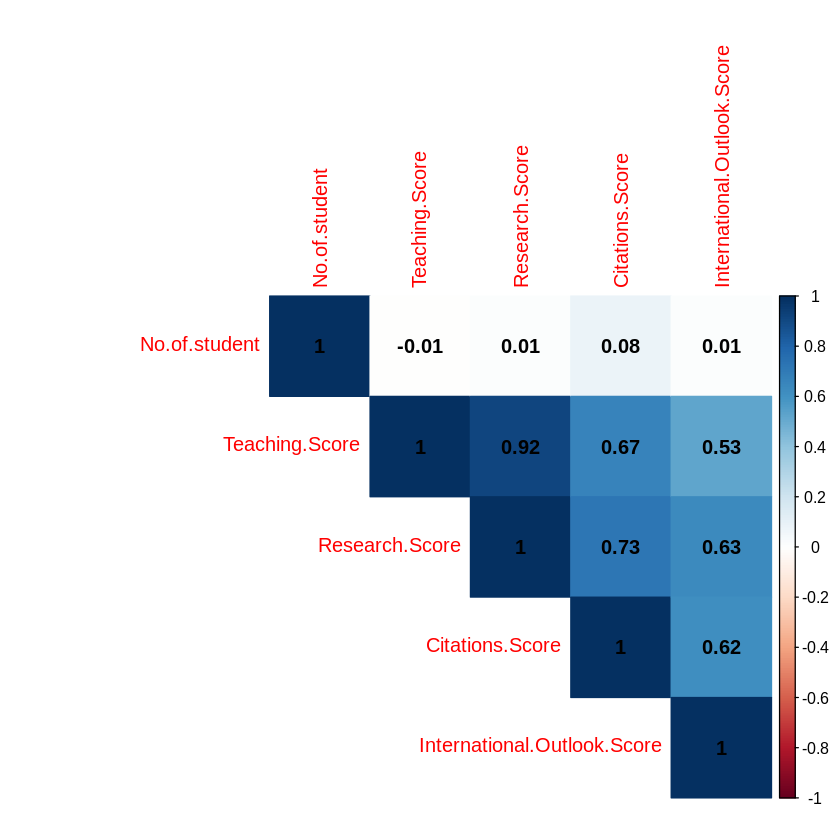

In [ ]:
install.packages("corrplot")
library(corrplot)
cor_matrix <- cor(ranking_data[, c("No.of.student", "Teaching.Score", "Research.Score", "Citations.Score", "International.Outlook.Score")])
corrplot(cor_matrix, method = "color", type = "upper", addCoef.col = "black")

Visualization

In [ ]:
library(corrplot)  # Loading corrplot library for visualization

# Select numerical columns for correlation analysis
numerical_data <- ranking_data[, c("No.of.student", "No.of.student.per.staff", "International.Student",
                                   "OverAll.Score", "Teaching.Score", "Research.Score",
                                   "Citations.Score", "Industry.Income.Score",
                                   "International.Outlook.Score", "Female_Ratio", "Male_Ratio")]

# Calculate the correlation matrix
correlation_matrix <- cor(numerical_data)
print(correlation_matrix)

# Printing the correlation matrix in a table format
write.table(correlation_matrix, "correlation_matrix_table.txt", sep="\t")

                            No.of.student No.of.student.per.staff
No.of.student                 1.000000000             0.430008185
No.of.student.per.staff       0.430008185             1.000000000
International.Student        -0.069842879            -0.086366440
OverAll.Score                 0.026344015            -0.108402050
Teaching.Score               -0.009051578            -0.153253297
Research.Score                0.013079443            -0.053795520
Citations.Score               0.084273666            -0.051157320
Industry.Income.Score        -0.025171781            -0.004569347
International.Outlook.Score   0.010314276            -0.033544145
Female_Ratio                  0.093844931             0.064139166
Male_Ratio                   -0.093844931            -0.064139166
                            International.Student OverAll.Score Teaching.Score
No.of.student                         -0.06984288    0.02634402   -0.009051578
No.of.student.per.staff               -0.08636644 

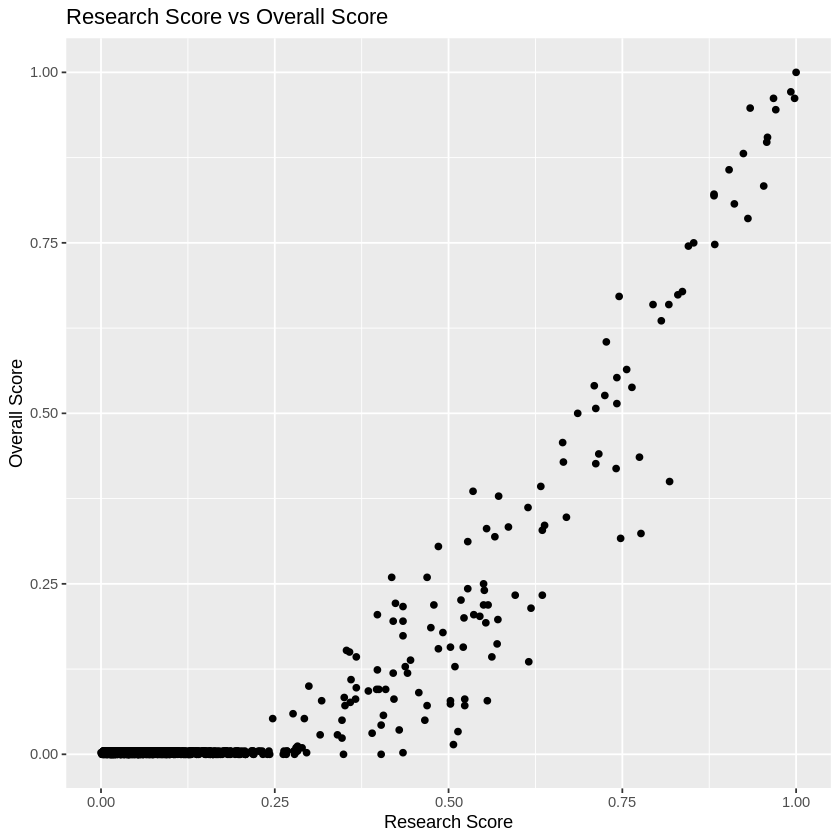

In [ ]:
library(ggplot2)

ggplot(ranking_data, aes(x = Research.Score, y = OverAll.Score)) +
  geom_point() +
  labs(title = "Research Score vs Overall Score", x = "Research Score", y = "Overall Score")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




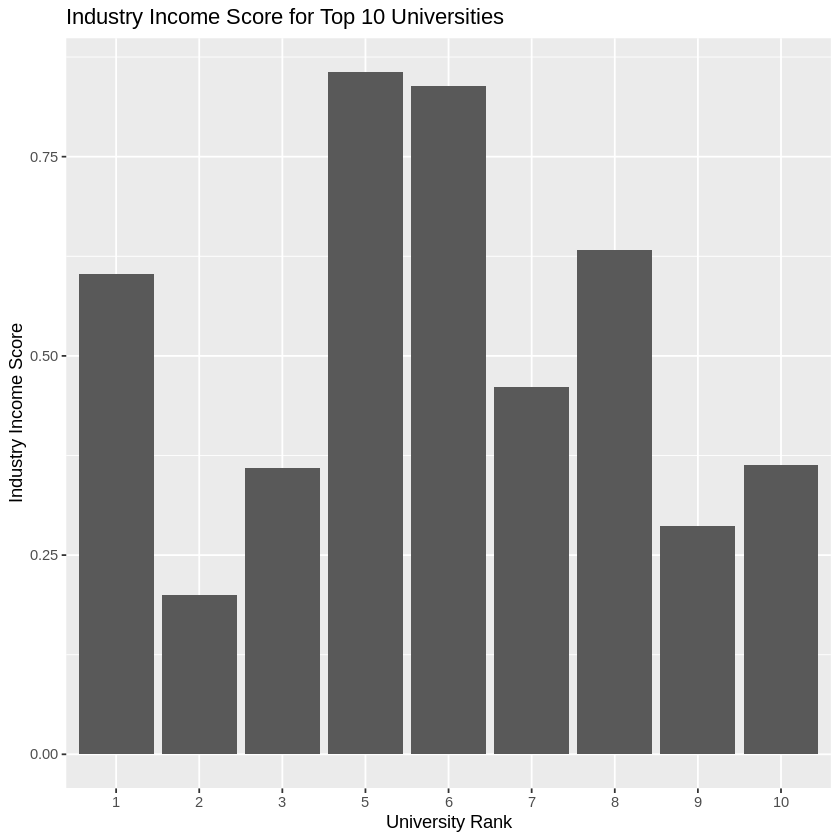

In [ ]:
library(dplyr)

# Assuming 'University.Rank' is numeric and lower numbers indicate higher ranks
top_10 <- ranking_data %>%
  arrange(University.Rank) %>%
  slice(1:10)

ggplot(top_10, aes(x = as.factor(University.Rank), y = Industry.Income.Score)) +
  geom_bar(stat = "summary", fun = "mean") +
  labs(title = "Industry Income Score for Top 10 Universities", x = "University Rank", y = "Industry Income Score")

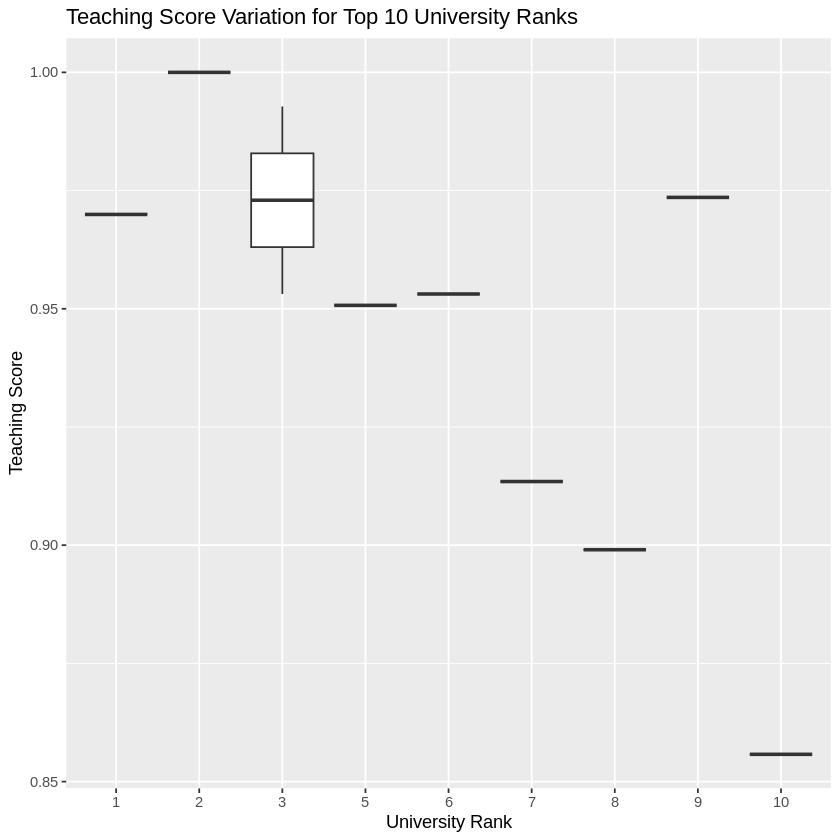

In [ ]:
library(dplyr)

top_10_ranks <- ranking_data %>%
  filter(University.Rank <= 10)

ggplot(top_10_ranks, aes(x = as.factor(University.Rank), y = Teaching.Score)) +
  geom_boxplot() +
  labs(title = "Teaching Score Variation for Top 10 University Ranks", x = "University Rank", y = "Teaching Score")

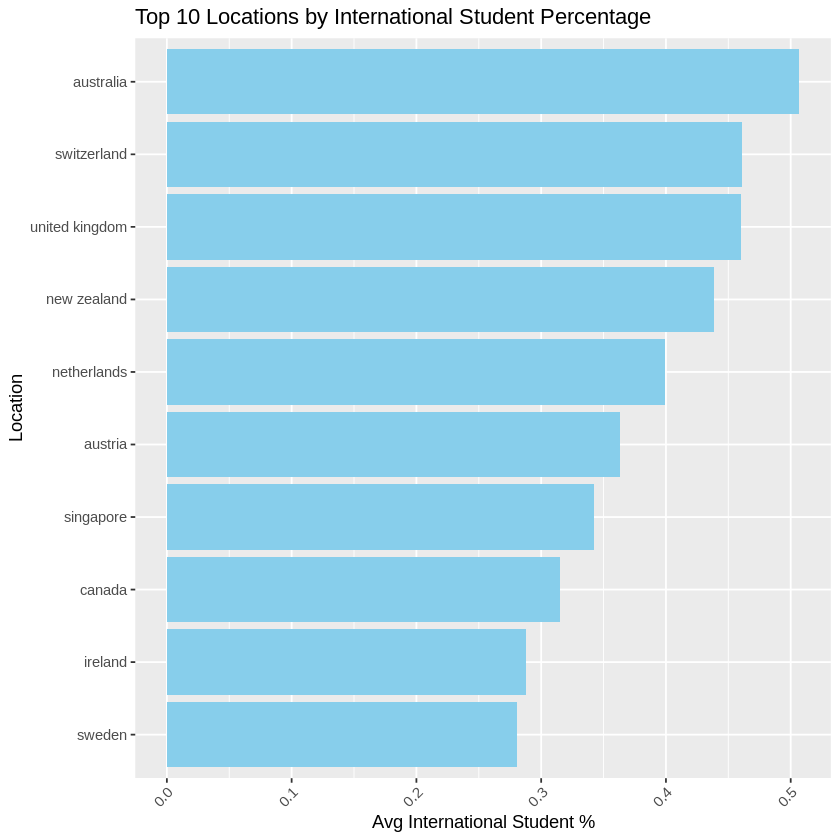

In [ ]:
library(dplyr)

# Calculate mean International Student percentage for each location
location_means <- ranking_data %>%
  group_by(Location) %>%
  summarize(Avg_International_Student = mean(International.Student, na.rm = TRUE)) %>%
  arrange(desc(Avg_International_Student))

# Select top 10 locations
top_10_locations <- head(location_means, 10)

# Bar plot for top 10 locations by International Student percentage
ggplot(top_10_locations, aes(x = reorder(Location, Avg_International_Student), y = Avg_International_Student)) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = "Top 10 Locations by International Student Percentage", x = "Location", y = "Avg International Student %") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  coord_flip()



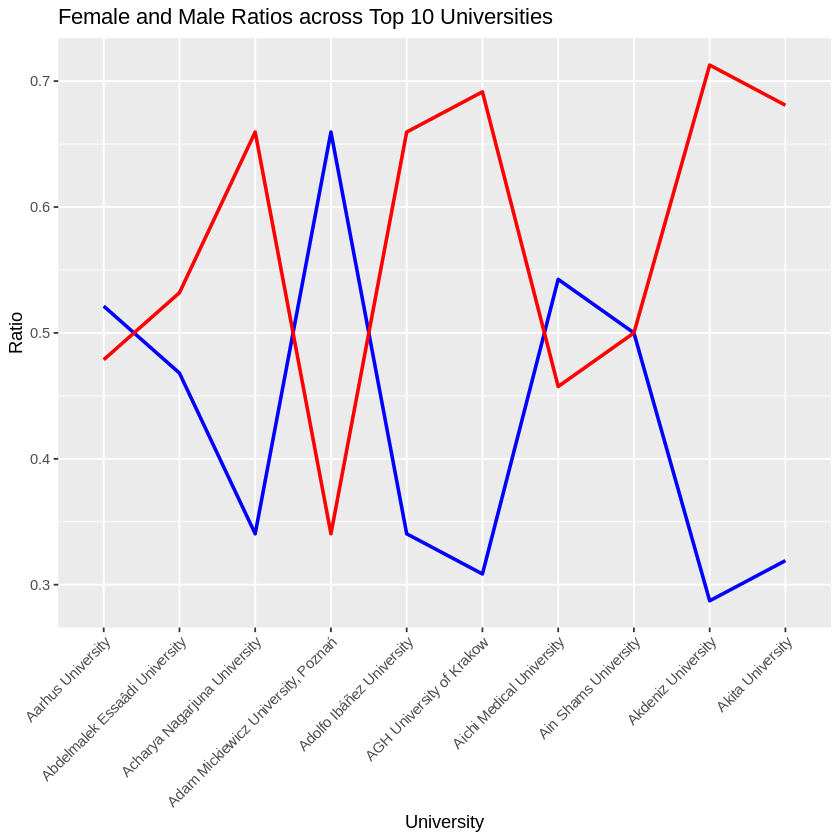

In [ ]:
# Assuming 'University.Rank' is numeric and lower numbers indicate higher ranks
top_10_universities <- ranking_data %>%
  arrange(Name.of.University) %>%
  slice(1:10)

ggplot(top_10_universities, aes(x = as.factor(Name.of.University), y = Female_Ratio, group = 1)) +
  geom_line(color = "blue", aes(y = Female_Ratio), linewidth = 1) +
  geom_line(color = "red", aes(y = Male_Ratio), linewidth = 1) +
  labs(title = "Female and Male Ratios across Top 10 Universities", x = "University", y = "Ratio") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

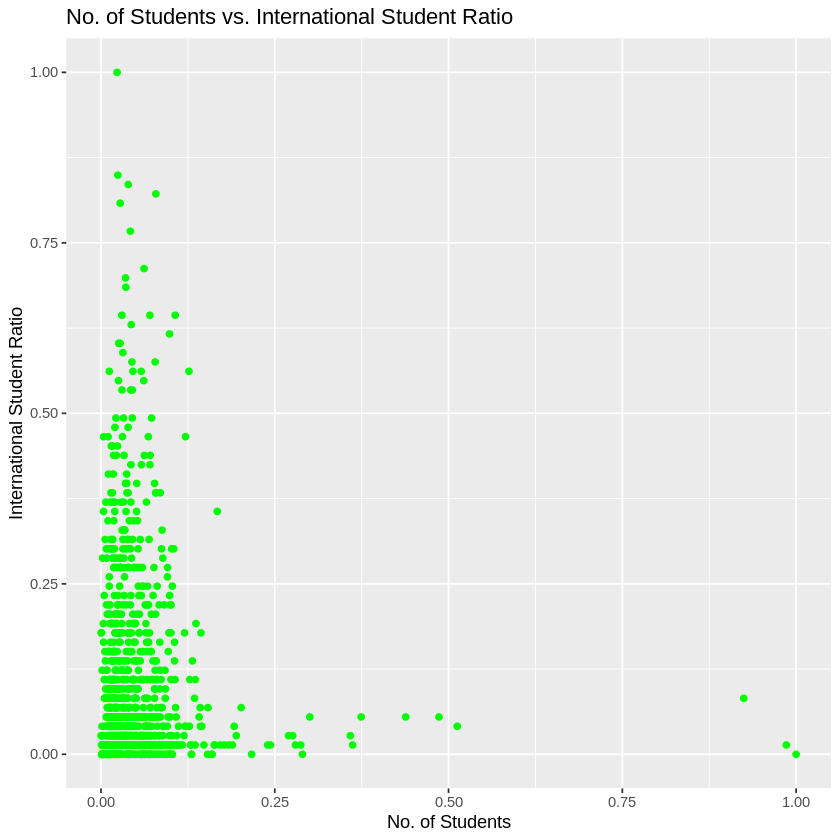

In [ ]:
ggplot(ranking_data, aes(x = No.of.student, y = International.Student)) +
  geom_point(color = "green") +
  labs(title = "No. of Students vs. International Student Ratio", x = "No. of Students", y = "International Student Ratio")


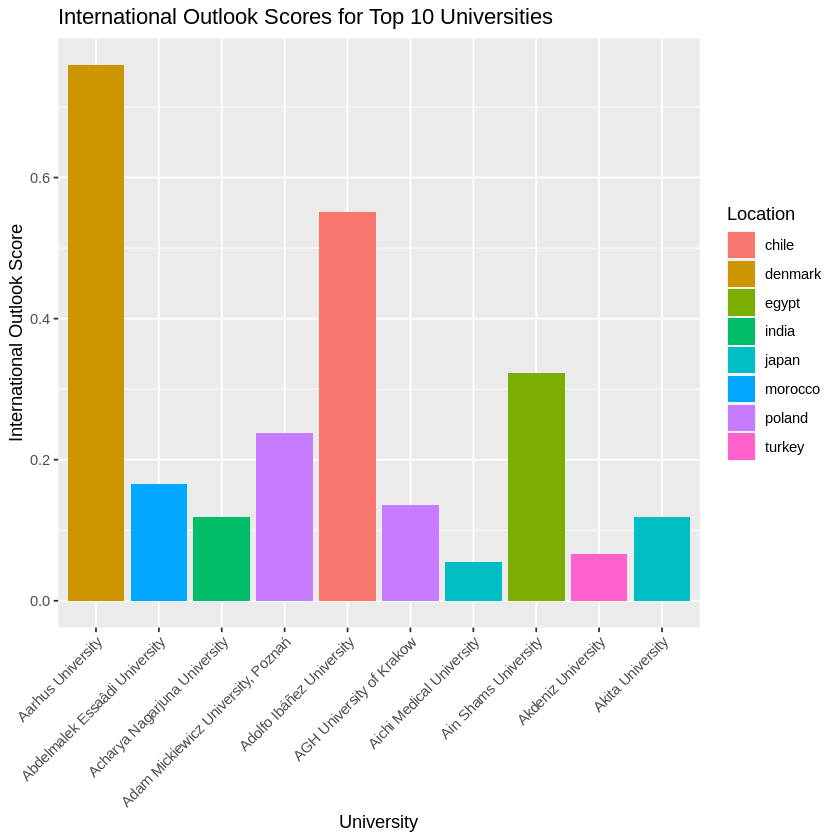

In [ ]:
ggplot(top_10_universities, aes(x = as.factor(Name.of.University), y = International.Outlook.Score, fill = Location)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "International Outlook Scores for Top 10 Universities", x = "University", y = "International Outlook Score") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

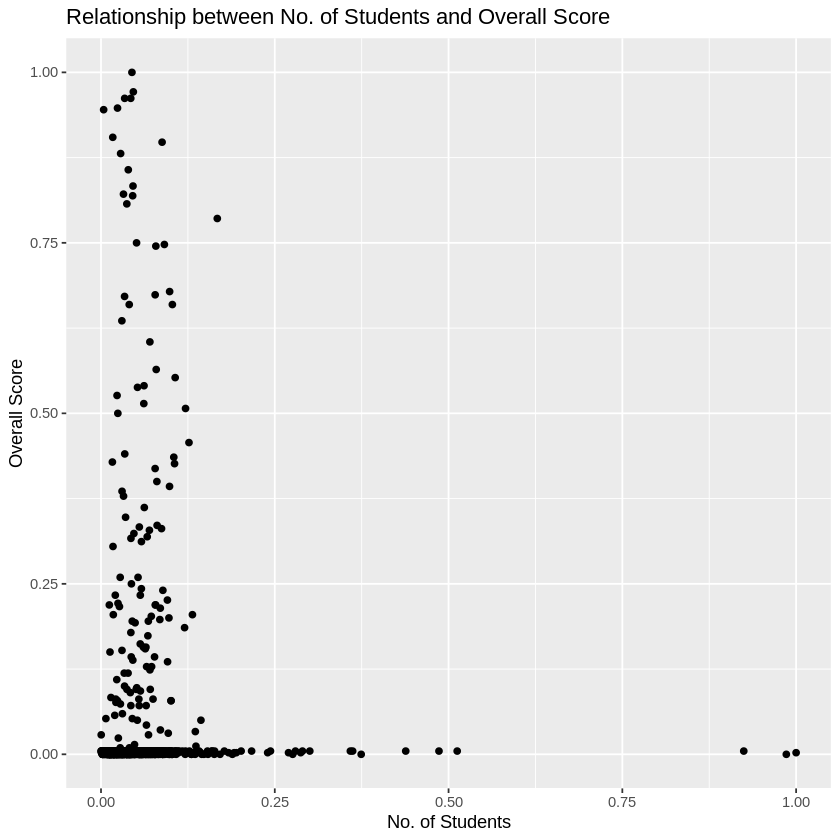

In [ ]:
ggplot(ranking_data, aes(x = No.of.student, y = OverAll.Score)) +
  geom_point() +
  labs(title = "Relationship between No. of Students and Overall Score", x = "No. of Students", y = "Overall Score")


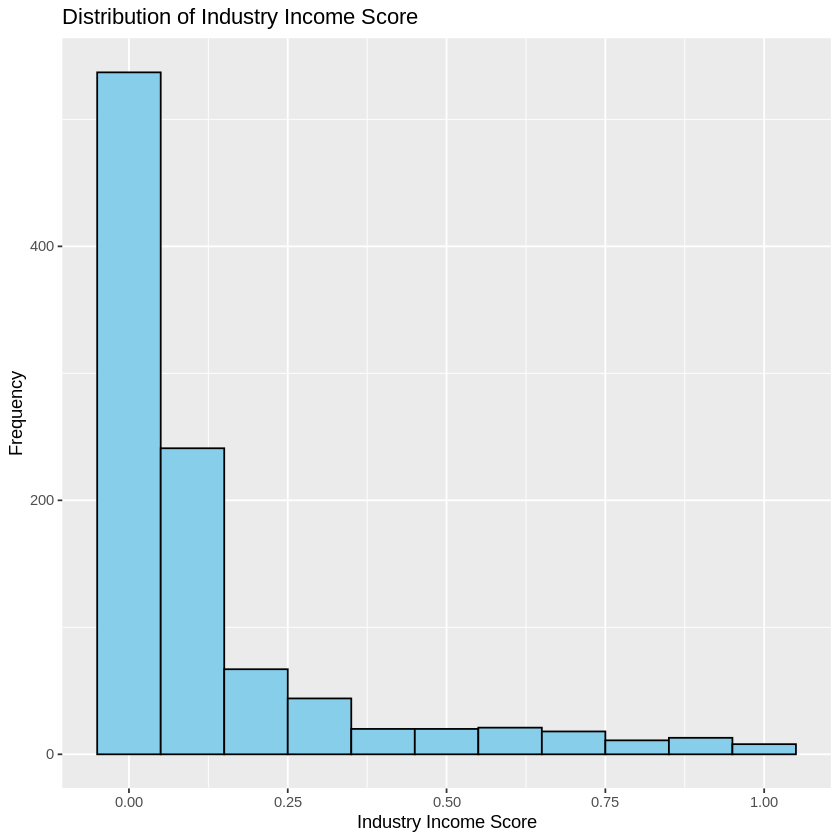

In [ ]:
ggplot(ranking_data, aes(x = Industry.Income.Score)) +
  geom_histogram(binwidth = 0.1, fill = "skyblue", color = "black") +
  labs(title = "Distribution of Industry Income Score", x = "Industry Income Score", y = "Frequency")

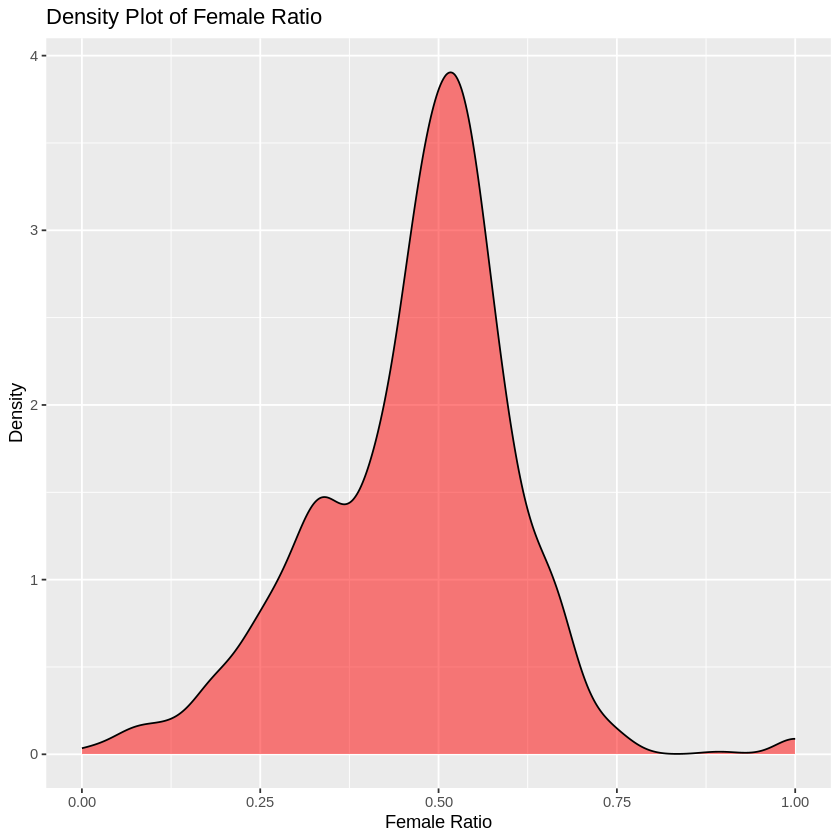

In [ ]:
ggplot(ranking_data, aes(x = Female_Ratio)) +
  geom_density(fill = "red", alpha = 0.5) +
  labs(title = "Density Plot of Female Ratio", x = "Female Ratio", y = "Density")

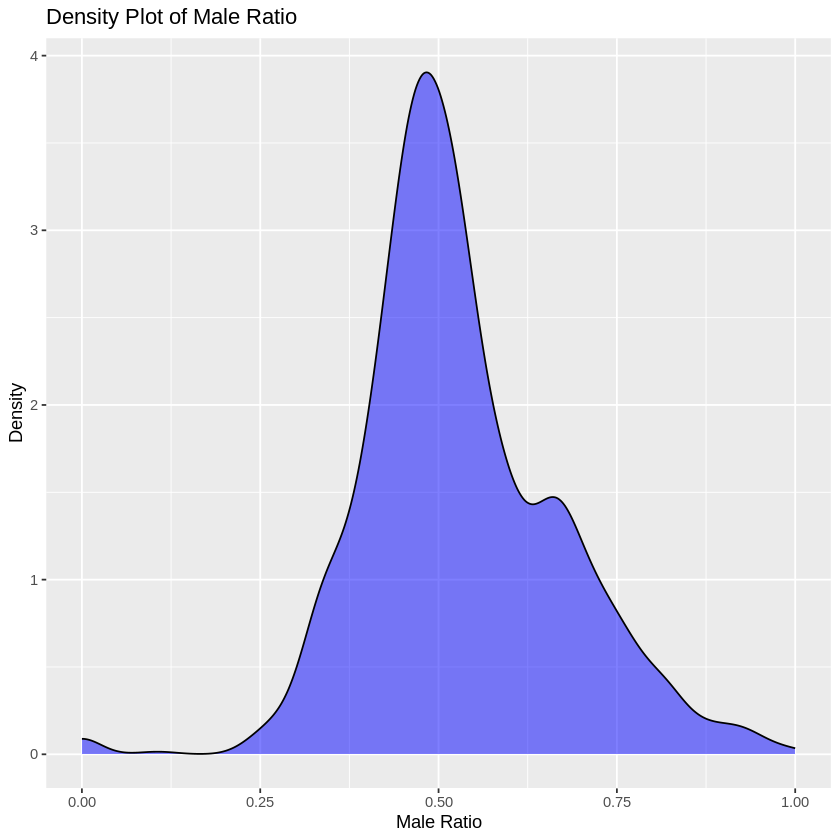

In [ ]:
ggplot(ranking_data, aes(x = Male_Ratio)) +
  geom_density(fill = "blue", alpha = 0.5) +
  labs(title = "Density Plot of Male Ratio", x = "Male Ratio", y = "Density")

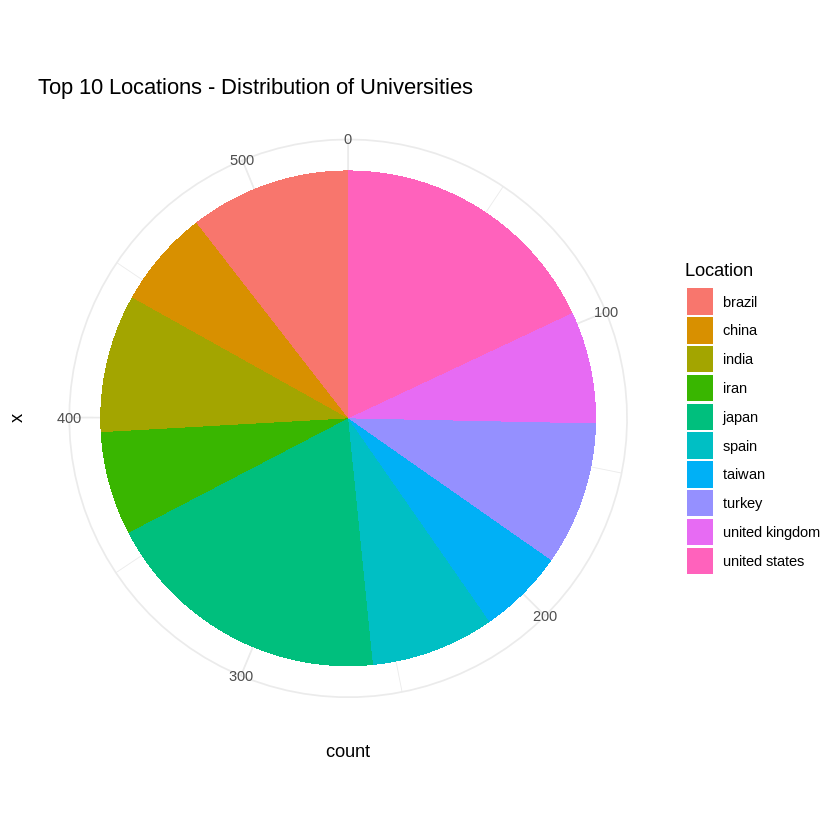

In [ ]:
library(dplyr)

top_10_locations <- ranking_data %>%
  group_by(Location) %>%
  summarise(Count = n()) %>%
  top_n(10, Count)

ranking_data_top10 <- ranking_data %>%
  filter(Location %in% top_10_locations$Location)

ggplot(ranking_data_top10, aes(x = "", fill = Location)) +
  geom_bar(width = 1) +
  coord_polar("y") +
  labs(title = "Top 10 Locations - Distribution of Universities", fill = "Location") +
  theme_minimal()

Extra Misc Work

In [ ]:
data_for_modeling <- ranking_data[, c(
  "No.of.student", "No.of.student.per.staff", "International.Student",
  "OverAll.Score", "Teaching.Score", "Research.Score",
  "Citations.Score", "Industry.Income.Score",
  "International.Outlook.Score", "Female_Ratio", "Male_Ratio", "University.Rank"
)]
# Identify columns with missing values
missing_cols <- colnames(data_for_modeling)[colSums(is.na(data_for_modeling)) > 0]

# Impute missing values for numerical columns with the mean
for (col in missing_cols) {
  if (is.numeric(data_for_modeling[[col]])) {
    mean_val <- mean(data_for_modeling[[col]], na.rm = TRUE)
    data_for_modeling[[col]][is.na(data_for_modeling[[col]])] <- mean_val
  } else {
    mode_val <- names(sort(table(data_for_modeling[[col]]), decreasing = TRUE))[1]
    data_for_modeling[[col]][is.na(data_for_modeling[[col]])] <- mode_val
  }
}

# Check for missing values again
any(is.na(data_for_modeling))

[1] FALSE

In [ ]:
# Load necessary libraries
install.packages('caret')
library(caret)

# Assume 'ranking_data' contains your dataset

# Select relevant columns for modeling
data_for_modeling <- ranking_data[, c("No.of.student", "No.of.student.per.staff", "International.Student",
                                           "OverAll.Score", "Teaching.Score", "Research.Score",
                                           "Citations.Score", "Industry.Income.Score",
                                           "International.Outlook.Score", "Female_Ratio", "Male_Ratio",
                                           "University.Rank"
)]

# Remove rows with missing values
cleaned_data <- na.omit(data_for_modeling)

# Split data into training and test sets
set.seed(123)
trainIndex <- createDataPartition(cleaned_data$University.Rank, p = 0.8, list = FALSE)
trainData <- cleaned_data[trainIndex, ]
testData <- cleaned_data[-trainIndex, ]

# Train the linear regression model
model <- train(
  University.Rank ~ .,
  data = trainData,
  method = "lm"
)

# Make predictions on the test set
predictions <- predict(model, newdata = testData)

# Evaluate the model
mse <- mean((predictions - testData$University.Rank)^2)  # Mean Squared Error
rmse <- sqrt(mse)  # Root Mean Squared Error
rsquared <- cor(predictions, testData$University.Rank)^2  # R-squared value

# Print the metrics
cat("Mean Squared Error (MSE):", mse, "\n")
cat("Root Mean Squared Error (RMSE):", rmse, "\n")
cat("R-squared value:", rsquared, "\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘timeDate’, ‘e1071’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Loading required package: lattice



Mean Squared Error (MSE): 7.461225e+12 
Root Mean Squared Error (RMSE): 2731524 
R-squared value: 0.183771 


The model, while showing some predictive capability with an R-squared value around 0.18, struggles with a high Root Mean Squared Error (RMSE)

In [ ]:
# Load necessary libraries
library(glmnet)

# Assuming 'ranking_data' contains your dataset

# Select relevant columns for modeling
data_for_modeling <- ranking_data[, c(
  "No.of.student", "No.of.student.per.staff", "International.Student",
  "OverAll.Score", "Teaching.Score", "Research.Score",
  "Citations.Score", "Industry.Income.Score",
  "International.Outlook.Score", "Female_Ratio", "Male_Ratio", "University.Rank"
)]

# Remove rows with missing values
cleaned_data <- na.omit(data_for_modeling)

# Define predictors and response variable
x <- as.matrix(cleaned_data[, -12])  # Features
y <- cleaned_data[, 12]  # Response (University.Rank)

# Perform Ridge Regression
ridge_model <- glmnet(x, y, alpha = 0, lambda = 0.1)
# Make predictions on the test set (assuming 'testData' is your test set)
predictions <- predict(ridge_model, newx = as.matrix(testData[, -12]))

# Evaluate the model using metrics like MSE, RMSE, R-squared
# Perform the evaluation using your test set (if available) to get metrics like MSE, RMSE, R-squared
# For example:
# Evaluate the model
mse <- mean((predictions - testData$University.Rank)^2)  # Mean Squared Error
rmse <- sqrt(mse)  # Root Mean Squared Error
rsquared <- cor(predictions, testData$University.Rank)^2  # R-squared value

# Print the metrics
cat("Mean Squared Error (MSE):", mse, "\n")
cat("Root Mean Squared Error (RMSE):", rmse, "\n")
cat("R-squared value:", rsquared, "\n")


Loading required package: Matrix

Loaded glmnet 4.1-8



Mean Squared Error (MSE): 7.402998e+12 
Root Mean Squared Error (RMSE): 2720845 
R-squared value: 0.1895034 


The model demonstrates some predictive ability with an R-squared value of approximately 0.19.

In [ ]:
# Load necessary libraries
library(rpart)

# Assuming 'data_for_modeling' contains your features and 'University.Rank' is the target variable

# Split data into training and test sets
set.seed(123)
trainIndex <- createDataPartition(data_for_modeling$University.Rank, p = 0.8, list = FALSE)
trainData <- data_for_modeling[trainIndex, ]
testData <- data_for_modeling[-trainIndex, ]

# Train the decision tree model
model_tree <- rpart(University.Rank ~ ., data = trainData)

# Make predictions on the test set
predictions_tree <- predict(model_tree, newdata = testData)

# Calculate Mean Squared Error (MSE)
mse <- mean((testData$University.Rank - predictions_tree)^2)

# Calculate Root Mean Squared Error (RMSE)
rmse <- sqrt(mse)

# Calculate R-squared value
actual <- testData$University.Rank
rsquared <- 1 - (sum((actual - predictions_tree)^2) / sum((actual - mean(actual))^2))

# Print the evaluation metrics
print(paste("Mean Squared Error (MSE):", round(mse, 4)))
print(paste("Root Mean Squared Error (RMSE):", round(rmse, 4)))
print(paste("R-squared value:", round(rsquared, 4)))


[1] "Mean Squared Error (MSE): 4332894251203.63"
[1] "Root Mean Squared Error (RMSE): 2081560.5327"
[1] "R-squared value: 0.5252"


R-squared value of about 0.53 suggest that the model captures a moderate amount of variance in the data. While the R-squared value indicates a fair proportion of the variance explained by the model

In [ ]:
# Load necessary libraries
install.packages('randomForest')
library(randomForest)

# Assuming 'ranking_data' contains your dataset

# Select relevant columns for modeling
data_for_modeling <- ranking_data[, c(
  "OverAll.Score", "Teaching.Score", "Research.Score", "University.Rank"
)]

# Remove rows with missing values
cleaned_data <- na.omit(data_for_modeling)

# Split data into training and test sets
set.seed(123)
trainIndex <- createDataPartition(cleaned_data$University.Rank, p = 0.8, list = FALSE)
trainData <- cleaned_data[trainIndex, ]
testData <- cleaned_data[-trainIndex, ]

# Train the Random Forest model
model_rf <- randomForest(University.Rank ~ ., data = trainData)

# Make predictions on the test set
predictions_rf <- predict(model_rf, newdata = testData)

# Evaluate the model
mse_rf <- mean((predictions_rf - testData$University.Rank)^2)  # Mean Squared Error
rmse_rf <- sqrt(mse_rf)  # Root Mean Squared Error
rsquared_rf <- cor(predictions_rf, testData$University.Rank)^2  # R-squared value

# Print the metrics
cat("Random Forest - Mean Squared Error (MSE):", mse_rf, "\n")
cat("Random Forest - Root Mean Squared Error (RMSE):", rmse_rf, "\n")
cat("Random Forest - R-squared value:", rsquared_rf, "\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin




Random Forest - Mean Squared Error (MSE): 8.77051e+12 
Random Forest - Root Mean Squared Error (RMSE): 2961505 
Random Forest - R-squared value: 0.06890647 


R-squared value of about 0.07. These metrics suggest that the model has a relatively high error rate and explains a small portion of the variance in the data